In [7]:
import zipfile

# This automatically extracts your data.csv from the archive.zip folder
with zipfile.ZipFile('archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("Unzipping complete!")

Unzipping complete!


1. Data Loading & Cleaning


In [8]:
import pandas as pd

# 1. Load the data properly
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# 2. Check for missing values (The most important first step!)
print("--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

# 3. See the data types (Are dates actually dates? Are numbers actually numbers?)
print("\n--- COLUMN DATA TYPES ---")
print(df.info())

# 4. Get a statistical summary (Check for negative prices or quantities)
print("\n--- STATISTICAL SUMMARY ---")
print(df.describe())

--- MISSING VALUES PER COLUMN ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- COLUMN DATA TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

--- STATISTICAL SUMMARY ---
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean       

In [9]:
# 1. Create a copy of the data to keep it safe
df_clean = df.copy()

# 2. Remove rows where CustomerID is missing
# We use dropna() to delete rows that have no Customer ID
df_clean = df_clean.dropna(subset=['CustomerID'])

# 3. Remove Returns/Cancellations
# We only want rows where Quantity and UnitPrice are greater than 0
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 4. Check the "Health" of the new dataset
print("--- CLEANING REPORT ---")
print(f"Original rows: {len(df)}")
print(f"Cleaned rows:  {len(df_clean)}")
print(f"Rows removed:  {len(df) - len(df_clean)}")

# 5. Verify that min values are now positive
print("\n--- NEW STATISTICAL SUMMARY ---")
print(df_clean[['Quantity', 'UnitPrice']].describe())

--- CLEANING REPORT ---
Original rows: 541909
Cleaned rows:  397884
Rows removed:  144025

--- NEW STATISTICAL SUMMARY ---
            Quantity      UnitPrice
count  397884.000000  397884.000000
mean       12.988238       3.116488
std       179.331775      22.097877
min         1.000000       0.001000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
max     80995.000000    8142.750000


In [10]:
# 1. Create the Total_Sales column
df_clean['Total_Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 2. Convert InvoiceDate to a real Date format
# This is crucial so Python understands '2011-12-01' is a date, not just text
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 3. Extract the Month and Year into a new column for easier charting
df_clean['Month_Year'] = df_clean['InvoiceDate'].dt.to_period('M')

# 4. View the new columns
print("--- UPDATED DATA PREVIEW ---")
print(df_clean[['InvoiceDate', 'Total_Sales', 'Month_Year']].head())

--- UPDATED DATA PREVIEW ---
          InvoiceDate  Total_Sales Month_Year
0 2010-12-01 08:26:00        15.30    2010-12
1 2010-12-01 08:26:00        20.34    2010-12
2 2010-12-01 08:26:00        22.00    2010-12
3 2010-12-01 08:26:00        20.34    2010-12
4 2010-12-01 08:26:00        20.34    2010-12


2. Revenue Analysis by Country

In [11]:
# Group by Country and sum the sales
country_sales = df_clean.groupby('Country')['Total_Sales'].sum().sort_values(ascending=False)

# Show the top 5 countries
print("--- TOP 5 COUNTRIES BY REVENUE ---")
print(country_sales.head(5))

--- TOP 5 COUNTRIES BY REVENUE ---
Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Name: Total_Sales, dtype: float64


3. Monthly Sales Trends

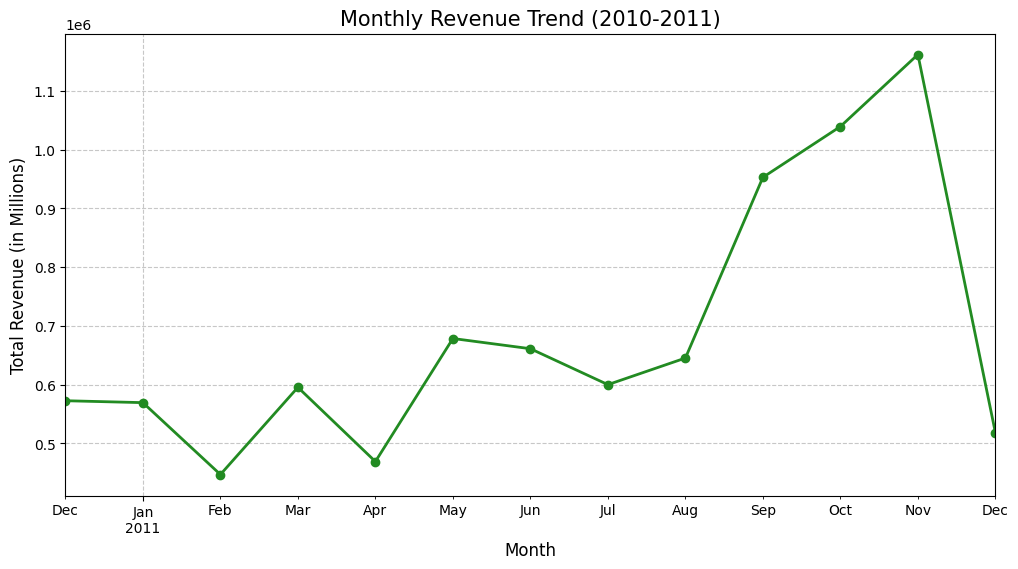

In [12]:
import matplotlib.pyplot as plt

# 1. Group by the Month/Year we created earlier and sum the sales
monthly_revenue = df_clean.groupby('Month_Year')['Total_Sales'].sum()

# 2. Plot the data
plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='forestgreen', linewidth=2)

# 3. Add labels and title
plt.title('Monthly Revenue Trend (2010-2011)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (in Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Show the chart
plt.show()